# Replication - comparing sources

Changes:
- Only 3 search queries per question
- Only 1 date range (between begin date and a week prior to resolution)
- Fetch articles from any source
- Calculate probabilities separately (per source)
- Compare Brier score between sources

## 0. Configuration

In [4]:
# ============================================================
# CELL 0 — Configuration
# This is the only cell you need to edit to change models, paths, or experiment settings.
# ============================================================

import os, sys

# ── Number of questions to evaluate ─────────────────────────
NUM_QUESTIONS = 70 # 840 total

# ── Models ──────────────────────────────────────────────────
# All LLM calls go through this model unless overridden below.
DEFAULT_MODEL = "llama-3.3-70b-versatile"

SEARCH_QUERY_MODEL    = DEFAULT_MODEL
RANKING_MODEL         = DEFAULT_MODEL
SUMMARIZATION_MODEL   = DEFAULT_MODEL
REASONING_MODEL       = DEFAULT_MODEL

# ── LLM Backend ─────────────────────────────────────────────
USE_LOCAL_LLM = True   # Set to False to use Groq instead

# ── Temperatures ────────────────────────────────────────────
SEARCH_QUERY_TEMPERATURE  = 0.0
RANKING_TEMPERATURE       = 0.0
SUMMARIZATION_TEMPERATURE = 0.2
REASONING_TEMPERATURE     = 1.0

# ── Retrieval settings ───────────────────────────────────────
RETRIEVAL_DAYS_BEFORE_RESOLUTION = 7
NUM_SEARCH_QUERIES     = 3    # total queries per question
NUM_ARTICLES_PER_QUERY = 10   # max articles to fetch per query
RELEVANCE_THRESHOLD    = 4    # 1-6 scale; keep articles rated >= this
TOP_K_ARTICLES         = 15   # keep top K after ranking
NUM_REASONING_PROMPTS  = 3    # number of scratchpad prompts to run

TRACKED_SOURCES = [
    "The New York Times",
    "The Washington Post",
]

# ── Paths ────────────────────────────────────────────────────
REPO_ROOT    = os.path.abspath("../../llm_forecasting")   # adjust if needed
DATA_PATH    = "../../data/validation.json"               # adjust if needed
OUTPUT_DIR   = "results_03"

QUERIES_FILE     = os.path.join(OUTPUT_DIR, "queries.json")
ARTICLES_FILE    = os.path.join(OUTPUT_DIR, "articles.json")
SUMMARIES_FILE   = os.path.join(OUTPUT_DIR, "summaries.json")
PREDICTIONS_FILE = os.path.join(OUTPUT_DIR, "predictions.json")

os.makedirs(OUTPUT_DIR, exist_ok=True)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Config OK")
print(f"  Model:      {DEFAULT_MODEL}")
print(f"  Questions:  {NUM_QUESTIONS}")
print(f"  Data:       {DATA_PATH}")
print(f"  Output dir: {OUTPUT_DIR}")

Config OK
  Model:      llama-3.3-70b-versatile
  Questions:  70
  Data:       ../../data/validation.json
  Output dir: results_03


## 1. Imports and helpers

In [5]:
import json
import math
import time
import asyncio
import logging
import os
import sys
import torch
from datetime import datetime, timedelta
from transformers import pipeline as hf_pipeline

import numpy as np
import requests
from bs4 import BeautifulSoup
from gnews import GNews
from googlenewsdecoder import gnewsdecoder

# ── Groq client (via openai-compatible API) ──────────────────
import openai
from config.keys import (
    GROQ_API_KEY_1,
    GROQ_API_KEY_2,
    GROQ_API_KEY_3,
    GROQ_API_KEY_4,
    GROQ_API_KEY_5,
)

GROQ_API_KEYS = [
    GROQ_API_KEY_1,
    GROQ_API_KEY_2,
    GROQ_API_KEY_3,
    GROQ_API_KEY_4,
    GROQ_API_KEY_5,
]

groq_clients = [
    openai.OpenAI(
        api_key=key,
        base_url="https://api.groq.com/openai/v1",
    )
    for key in GROQ_API_KEYS
]

exhausted_keys = set()
current_client_idx = 0

# ── Local LLM setup ──────────────────────────────────────────
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

LOCAL_MODEL_PATH = "/SWS/llms/nobackup/hub/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28"

local_pipe = None  # loaded lazily on first call

def _get_local_pipe():
    global local_pipe
    if local_pipe is None:
        print("Loading local model (first call only, takes ~2 min)...")
        local_pipe = hf_pipeline(
            "text-generation",
            model=LOCAL_MODEL_PATH,
            torch_dtype=torch.bfloat16,
            device_map="auto",
        )
        print("Local model ready.")
    return local_pipe

# ── Logging ──────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ── Groq LLM call ────────────────────────────────────────────
def call_llm_groq(prompt, model=None, temperature=0.0, max_tokens=4096):
    global current_client_idx, exhausted_keys
    model = model or DEFAULT_MODEL
    while True:
        if len(exhausted_keys) == len(groq_clients):
            raise RuntimeError("All Groq API keys are exhausted.")
        if current_client_idx in exhausted_keys:
            current_client_idx = (current_client_idx + 1) % len(groq_clients)
            continue
        client = groq_clients[current_client_idx]
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature,
                max_tokens=max_tokens,
            )
            return response.choices[0].message.content
        except Exception as e:
            err = str(e).lower()
            quota_error = any(x in err for x in [
                "quota", "credit", "exceeded", "rate limit",
                "insufficient", "billing", "429",
            ])
            if quota_error:
                logger.warning(f"API key #{current_client_idx + 1} exhausted. Switching to next key.")
                exhausted_keys.add(current_client_idx)
                current_client_idx = (current_client_idx + 1) % len(groq_clients)
                continue
            logger.warning(f"LLM call failed with key #{current_client_idx + 1}: {e}. Retrying in 10s...")
            time.sleep(10)

# ── Local LLM call ───────────────────────────────────────────
def call_llm_local(prompt, model=None, temperature=0.0, max_tokens=4096):
    pipe = _get_local_pipe()
    # temperature=0 means greedy decoding
    do_sample = temperature > 0
    messages = [{"role": "user", "content": prompt}]
    out = pipe(
        messages,
        max_new_tokens=max_tokens,
        temperature=temperature if do_sample else None,
        do_sample=do_sample,
    )
    return out[0]["generated_text"][-1]["content"]

def call_llm_local_batch(prompts_list, temperature=0.0, max_tokens=4096):
    """Process a list of prompts in one GPU batch. Returns a list of responses."""
    pipe = _get_local_pipe()
    do_sample = temperature > 0
    messages_list = [[{"role": "user", "content": p}] for p in prompts_list]
    outputs = pipe(
        messages_list,
        max_new_tokens=max_tokens,
        temperature=temperature if do_sample else None,
        do_sample=do_sample,
        batch_size=8,  # process 8 at a time
    )
    return [out[0]["generated_text"][-1]["content"] for out in outputs]

# ── Unified call_llm — respects USE_LOCAL_LLM flag ───────────
def call_llm(prompt, model=None, temperature=0.0, max_tokens=4096):
    if USE_LOCAL_LLM:
        return call_llm_local(prompt, model=model, temperature=temperature, max_tokens=max_tokens)
    else:
        return call_llm_groq(prompt, model=model, temperature=temperature, max_tokens=max_tokens)

# ── JSON file helpers ─────────────────────────────────────────
def load_json(path):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return []

def save_json(path, data):
    with open(path, "w") as f:
        json.dump(data, f, indent=2, default=str)

# ── Date helpers ─────────────────────────────────────────────
def get_single_retrieval_date(date_begin, date_close, date_resolve):
    date_begin_obj   = datetime.strptime(date_begin, "%Y-%m-%d")
    date_close_obj   = datetime.strptime(date_close, "%Y-%m-%d")
    date_resolve_obj = datetime.strptime(date_resolve, "%Y-%m-%d")
    end_date = min(date_close_obj, date_resolve_obj)
    total_days = (end_date - date_begin_obj).days
    if total_days <= 0:
        return date_begin
    offset = min(RETRIEVAL_DAYS_BEFORE_RESOLUTION, total_days)
    retrieval_date = end_date - timedelta(days=offset)
    if retrieval_date < date_begin_obj:
        retrieval_date = date_begin_obj
    return retrieval_date.strftime("%Y-%m-%d")

def get_crowd_prediction_at_date(retrieval_date, community_predictions):
    ref = datetime.strptime(retrieval_date, "%Y-%m-%d")
    candidates = [p for p in community_predictions if datetime.strptime(p[0], "%Y-%m-%d") <= ref]
    if not candidates:
        candidates = community_predictions
    closest = min(candidates, key=lambda p: abs((datetime.strptime(p[0], "%Y-%m-%d") - ref).days))
    return closest[1] if closest else None

def brier_score(prediction, resolution):
    return (prediction - resolution) ** 2

def extract_prediction(response_text):
    import re
    if not response_text:
        return None
    matches = re.findall(r"\*([01]?\.\d+)\*", response_text)
    if matches:
        return float(matches[-1])
    for line in reversed(response_text.strip().split("\n")[-5:]):
        nums = re.findall(r"\b([01]?\.\d+)\b", line)
        for n in reversed(nums):
            v = float(n)
            if 0.0 <= v <= 1.0:
                return v
    return None

print("Cell 1 OK — LLM client and helpers ready")
print(f"  Backend: {'LOCAL (Qwen2.5-7B)' if USE_LOCAL_LLM else 'Groq API'}")

/SWS/llms/nobackup/snicolet/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cell 1 OK — LLM client and helpers ready
  Backend: LOCAL (Qwen2.5-7B)


## 2. Loading questions

In [6]:
# ============================================================
# CELL 2 — Load questions from validation.json
# ============================================================

with open(DATA_PATH) as f:
    all_questions = json.load(f)

questions_to_run = all_questions[:NUM_QUESTIONS]

print(f"Loaded {len(all_questions)} questions total.")
print(f"Running on {len(questions_to_run)} question(s):\n")
for i, q in enumerate(questions_to_run):
    community_preds = json.loads(q["community_predictions"])
    retrieval_date = get_single_retrieval_date(
        q["date_begin"],
        q["date_close"],
        q["date_resolve_at"],
    )
    print(f"  [{i}] {q['question']}")
    print(f"       Source:     {q['data_source']}")
    print(f"       Date range: {q['date_begin']} → {q['date_close']}")
    print(f"       Resolution: {q['resolution']} (resolved: {q['is_resolved']})")
    print(f"       Retrieval date:  {retrieval_date}")
    print(f"       Community predictions: {len(community_preds)} data points")
    print()

Loaded 840 questions total.
Running on 70 question(s):

  [0] Will S&P 500 increase in April 2023?
       Source:     manifold
       Date range: 2023-04-03 → 2023-05-02
       Resolution: 1 (resolved: True)
       Retrieval date:  2023-04-25
       Community predictions: 539 data points

  [1] Will Mathieu van der Poel win Paris-Roubaix 2023?
       Source:     manifold
       Date range: 2023-04-03 → 2023-04-09
       Resolution: 1 (resolved: True)
       Retrieval date:  2023-04-03
       Community predictions: 30 data points

  [2] Boston Marathon: Will the men's podium consist entirely of Kenyan or Ethiopian runners?
       Source:     manifold
       Date range: 2023-04-03 → 2023-04-17
       Resolution: 0 (resolved: True)
       Retrieval date:  2023-04-10
       Community predictions: 25 data points

  [3] Boston Marathon: Will the women's podium consist entirely of Kenyan or Ethiopian runners?
       Source:     manifold
       Date range: 2023-04-03 → 2023-04-17
       Resolu

## 3. Generating search queries

In [7]:
# ============================================================
# CELL 3 — Generate search queries
# Saves to queries.json. Skips questions already processed
# unless FORCE_RERUN_QUERIES = True.
# ============================================================

import re
from prompts.search_query import SEARCH_QUERY_PROMPT_0

FORCE_RERUN_QUERIES = False
MAX_WORDS           = 7
NUM_KEYWORDS        = 3 

def fill_search_query_prompt(template, question, background, date_begin, date_end,
                              num_keywords, max_words):
    prompt_str, _ = template
    return prompt_str.format(
        question=question,
        background=background,
        date_begin=date_begin,
        date_end=date_end,
        num_keywords=num_keywords,
        max_words=max_words,
    )

def extract_queries_from_response(response_text):
    """
    Parse the semicolon-separated queries from the 'Search Queries:' section.
    Returns a list of query strings.
    """
    if not response_text:
        return []
    # Find everything after "Search Queries:"
    match = re.search(r"Search Queries:\s*(.+)", response_text, re.DOTALL | re.IGNORECASE)
    if not match:
        return []
    raw = match.group(1).strip()
    # Split on semicolons, clean up
    queries = [q.strip().strip("{}").strip() for q in raw.split(";")]
    queries = [q for q in queries if q and len(q) > 3]
    return queries

# ── Load existing data ────────────────────────────────────────
queries_data   = load_json(QUERIES_FILE)
queries_lookup = {entry["question"]: entry for entry in queries_data}

# ── Main loop ─────────────────────────────────────────────────
for q in questions_to_run:
    question   = q["question"]
    background = q["background"]
    date_close = q["date_close"]
    print(f"\nQuestion: {question[:80]}")

    retrieval_date = get_single_retrieval_date(
        q["date_begin"],
        q["date_close"],
        q["date_resolve_at"],
    )

    # Get or create entry for this question
    if question not in queries_lookup:
        queries_lookup[question] = {
            "question":               question,
            "resolution":             float(q["resolution"]),
            "date_begin":             q["date_begin"],
            "date_close":             q["date_close"],
            "date_resolve_at":        q["date_resolve_at"],
            "retrieval_dates":        [retrieval_date],
            "retrieval_date_queries": {}
        }

    entry           = queries_lookup[question]
    existing_dates  = entry["retrieval_date_queries"]

    for retrieval_date in [retrieval_date]:
        if not FORCE_RERUN_QUERIES and retrieval_date in existing_dates:
            print(f"  [{retrieval_date}] Already generated — skipping.")
            continue

        print(f"  [{retrieval_date}] Generating queries...")
        date_results = {}

        prompt_template = SEARCH_QUERY_PROMPT_0
        prompt_name     = "prompt_0"
        prompt = fill_search_query_prompt(
            prompt_template,
            question=question,
            background=background,
            date_begin=q["date_begin"],
            date_end=retrieval_date,
            num_keywords=NUM_KEYWORDS,
            max_words=MAX_WORDS,
        )
        response = call_llm(
            prompt,
            model=SEARCH_QUERY_MODEL,
            temperature=SEARCH_QUERY_TEMPERATURE,
        )
        queries = extract_queries_from_response(response)

        date_results[prompt_name] = {
            "llm_response": response,
            "queries":      queries,
        }
        print(f"    [{prompt_name}] {len(queries)} queries: {queries}")

        existing_dates[retrieval_date] = date_results

        # Save after every retrieval date
        save_json(QUERIES_FILE, list(queries_lookup.values()))

print(f"\nDone. Saved to {QUERIES_FILE}")


Question: Will S&P 500 increase in April 2023?
  [2023-04-25] Already generated — skipping.

Question: Will Mathieu van der Poel win Paris-Roubaix 2023?
  [2023-04-03] Already generated — skipping.

Question: Boston Marathon: Will the men's podium consist entirely of Kenyan or Ethiopian r
  [2023-04-10] Already generated — skipping.

Question: Boston Marathon: Will the women's podium consist entirely of Kenyan or Ethiopian
  [2023-04-10] Already generated — skipping.

Question: Boston Marathon: Will a US runner place in the top 5 in the women's division?
  [2023-04-10] Already generated — skipping.

Question: Will Donald Trump get gag order in Manhattan DA case?
  [2023-04-03] Already generated — skipping.

Question: Boston Marathon: Will a US runner place in the top 10 in the men's division?
  [2023-04-10] Already generated — skipping.

Question: Will Wout van Aert win Paris-Roubaix 2023?
  [2023-04-03] Already generated — skipping.

Question: Will Mads Pedersen win Paris-Roubaix 202

## 4. Fetching articles

In [8]:
# ============================================================
# CELL 4 — Fetch articles from GNews
# For each query:
#   - fetch top articles from GNews
#   - decode URLs
#
# Does NOT scrape full text yet.
#
# Saves to articles.json.
# Skips already-fetched queries unless FORCE_RERUN_ARTICLES = True.
# ============================================================

from gnews import GNews
from googlenewsdecoder import gnewsdecoder
from functools import lru_cache

FORCE_RERUN_ARTICLES = False

def fetch_gnews_articles(query, date_begin, date_end, max_results=10):
    start = datetime.strptime(date_begin, "%Y-%m-%d")
    end   = datetime.strptime(date_end, "%Y-%m-%d")

    gn = GNews(
        language="en",
        country="US",
        start_date=(start.year, start.month, start.day),
        end_date=(end.year, end.month, end.day),
        max_results=max_results,
    )

    try:
        results = gn.get_news(query)
        return results if results else []
    except Exception as e:
        logger.warning(f"GNews fetch failed for '{query}': {e}")
        return []


@lru_cache(maxsize=1000)
def decode_google_news_url(google_url):
    try:
        result = gnewsdecoder(google_url, interval=1)
        if result.get("status"):
            return result["decoded_url"]
    except Exception:
        pass
    return google_url


def parse_article_metadata(raw, query):
    google_url  = raw.get("url", "")
    decoded_url = decode_google_news_url(google_url)

    return {
        "title":          raw.get("title"),
        "published_date": raw.get("published date"),
        "source":         raw.get("publisher", {}).get("title"),
        "source_url":     raw.get("publisher", {}).get("href"),
        "google_news_url": google_url,
        "url":            decoded_url,
        "query":          query,
        "text":           None,   # filled in scraping step
    }


# ── Load data ────────────────────────────────────────────────
queries_data    = load_json(QUERIES_FILE)
articles_data   = load_json(ARTICLES_FILE)
articles_lookup = {e["question"]: e for e in articles_data}


# ── Main loop ────────────────────────────────────────────────
for q_entry in queries_data:
    question = q_entry["question"]
    print(f"\nQuestion: {question[:80]}")

    if question not in articles_lookup:
        articles_lookup[question] = {
            "question": question,
            "resolution": q_entry["resolution"],
            "date_begin": q_entry["date_begin"],
            "date_close": q_entry["date_close"],
            "date_resolve_at": q_entry["date_resolve_at"],
            "retrieval_dates": q_entry["retrieval_dates"],
            "retrieval_date_articles": {}
        }

    entry   = articles_lookup[question]
    date_art = entry["retrieval_date_articles"]
    
    # Track changes for batch saving
    batch_counter = 0
    BATCH_SAVE_SIZE = 10

    for retrieval_date, prompt_results in q_entry["retrieval_date_queries"].items():
        if retrieval_date not in date_art:
            date_art[retrieval_date] = {}

        # Use set for O(1) deduplication instead of list
        all_queries = set()
        for _, prompt_data in prompt_results.items():
            all_queries.update(prompt_data.get("queries", []))

        for query in all_queries:
            if not FORCE_RERUN_ARTICLES and query in date_art[retrieval_date]:
                print(f"  [{retrieval_date}] '{query[:50]}' already exists")
                continue

            print(f"  [{retrieval_date}] Fetching: '{query[:60]}'")

            raw_articles = fetch_gnews_articles(
                query,
                date_begin=q_entry["date_begin"],
                date_end=retrieval_date,
                max_results=10
            )

            print(f"    Returned {len(raw_articles)} articles")

            parsed = []
            for raw in raw_articles:
                meta = parse_article_metadata(raw, query)
                print(f"    → [{meta['source']}] {meta['title'][:60] if meta['title'] else 'N/A'}")
                parsed.append(meta)

            # FLAT LIST (no grouping by source)
            date_art[retrieval_date][query] = parsed
            
            batch_counter += 1
            
            # Save in batches to reduce I/O
            if batch_counter >= BATCH_SAVE_SIZE:
                save_json(ARTICLES_FILE, list(articles_lookup.values()))
                batch_counter = 0
                print(f"    [Saved checkpoint]")

    # Final save for this question's remaining items
    if batch_counter > 0:
        save_json(ARTICLES_FILE, list(articles_lookup.values()))

print("\nDone. Saved to", ARTICLES_FILE)


Question: Will S&P 500 increase in April 2023?
  [2023-04-25] 'US economic outlook 2023' already exists
  [2023-04-25] 'S&P 500 April forecast' already exists
  [2023-04-25] 'Market trends April 2023' already exists

Question: Will Mathieu van der Poel win Paris-Roubaix 2023?
  [2023-04-03] 'Mathieu van der Poel injury update' already exists
  [2023-04-03] 'Mathieu van der Poel form 2023' already exists
  [2023-04-03] 'Van der Poel Paris-Roubaix results' already exists

Question: Boston Marathon: Will the men's podium consist entirely of Kenyan or Ethiopian r
  [2023-04-10] 'Boston Marathon men's favorites' already exists
  [2023-04-10] 'Ethiopian runners Boston Marathon' already exists
  [2023-04-10] 'Kenyan runners dominate Boston' already exists

Question: Boston Marathon: Will the women's podium consist entirely of Kenyan or Ethiopian
  [2023-04-10] 'Boston Marathon women's contenders 2023' already exists
  [2023-04-10] 'Kenyan women Boston Marathon favorites' already exists
  [20

## 5. Scraping articles' full text

In [9]:
# ============================================================
# CELL 5 — Scrape full text of articles
# Reads articles.json, scrapes full text for each unique URL,
# saves to scraped_articles.json.
# ============================================================

import requests
from bs4 import BeautifulSoup

FORCE_RERUN_SCRAPING = False

SCRAPED_FILE      = os.path.join(OUTPUT_DIR, "scraped_articles.json")
SCRAPE_TIMEOUT    = 1
SCRAPE_MIN_LENGTH = 200

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}


def scrape_article_text(url):
    if not url or url.startswith("https://news.google.com"):
        return None

    try:
        resp = requests.get(url, headers=HEADERS, timeout=SCRAPE_TIMEOUT)
        if resp.status_code != 200:
            return None

        soup = BeautifulSoup(resp.text, "html.parser")

        for tag in soup(["script", "style", "nav", "header", "footer",
                         "aside", "form", "noscript", "iframe"]):
            tag.decompose()

        article_tag = (
            soup.find("article") or
            soup.find("main") or
            soup.find("div", {"class": lambda c: c and "article" in c.lower()}) or
            soup.find("div", {"class": lambda c: c and "content" in c.lower()}) or
            soup.body
        )

        if not article_tag:
            return None

        paragraphs = article_tag.find_all("p")
        text = " ".join(
            p.get_text(separator=" ", strip=True) for p in paragraphs
        )
        text = " ".join(text.split())

        if len(text) < SCRAPE_MIN_LENGTH:
            return None

        return text

    except Exception:
        return None


# ── Load data ────────────────────────────────────────────────
articles_data  = load_json(ARTICLES_FILE)
scraped_data   = load_json(SCRAPED_FILE)
scraped_lookup = {e["question"]: e for e in scraped_data}

# ── URL cache (avoid re-scraping globally) ────────────────────
url_cache = {}

for entry in scraped_data:
    for date_articles in entry.get("retrieval_date_articles", {}).values():
        for query_articles in date_articles.values():

            # query_articles should be a list of article dicts
            if isinstance(query_articles, list):
                for art in query_articles:
                    if isinstance(art, dict):
                        url = art.get("url")
                        text = art.get("text")
                        if url and text:
                            url_cache[url] = text

            # defensive fallback (in case of corrupted structure)
            elif isinstance(query_articles, dict):
                for art in query_articles.values():
                    if isinstance(art, list):
                        for a in art:
                            if isinstance(a, dict):
                                url = a.get("url")
                                text = a.get("text")
                                if url and text:
                                    url_cache[url] = text


# ── Main loop ────────────────────────────────────────────────
for art_entry in articles_data:
    question = art_entry["question"]

    print(f"\n{'='*60}")
    print(f"Question: {question[:80]}")
    print('='*60)

    if question not in scraped_lookup:
        scraped_lookup[question] = {
            "question": question,
            "resolution": art_entry["resolution"],
            "date_begin": art_entry["date_begin"],
            "date_close": art_entry["date_close"],
            "date_resolve_at": art_entry["date_resolve_at"],
            "retrieval_dates": art_entry["retrieval_dates"],
            "retrieval_date_articles": {}
        }

    scraped_entry = scraped_lookup[question]
    date_out = scraped_entry["retrieval_date_articles"]

    for retrieval_date, query_articles in art_entry["retrieval_date_articles"].items():
        if retrieval_date not in date_out:
            date_out[retrieval_date] = {}

        print(f"\n  [{retrieval_date}]")

        for query, articles in query_articles.items():
            if not FORCE_RERUN_SCRAPING and query in date_out[retrieval_date]:
                print(f"    '{query[:50]}' already scraped")
                continue

            print(f"    Scraping: '{query[:60]}' ({len(articles)})")

            scraped_articles = []

            for i, art in enumerate(articles):
                url = art.get("url")
                title = (art.get("title") or "")[:60]

                if not FORCE_RERUN_SCRAPING and url in url_cache:
                    text = url_cache[url]
                    status = "cached"
                else:
                    text = scrape_article_text(url)
                    url_cache[url] = text
                    status = "scraped" if text else "failed"
                    time.sleep(0.5)

                print(f"      [{i+1}/{len(articles)}] [{status}] {title}")

                scraped_articles.append({**art, "text": text})

            date_out[retrieval_date][query] = scraped_articles

            save_json(SCRAPED_FILE, list(scraped_lookup.values()))

print("\nDone. Saved to", SCRAPED_FILE)


Question: Will S&P 500 increase in April 2023?

  [2023-04-25]
    'S&P 500 April forecast' already scraped
    'US economic outlook 2023' already scraped
    'Market trends April 2023' already scraped

Question: Will Mathieu van der Poel win Paris-Roubaix 2023?

  [2023-04-03]
    'Van der Poel Paris-Roubaix results' already scraped
    'Mathieu van der Poel form 2023' already scraped
    'Mathieu van der Poel injury update' already scraped

Question: Boston Marathon: Will the men's podium consist entirely of Kenyan or Ethiopian r

  [2023-04-10]
    'Kenyan runners dominate Boston' already scraped
    'Boston Marathon men's favorites' already scraped
    'Ethiopian runners Boston Marathon' already scraped

Question: Boston Marathon: Will the women's podium consist entirely of Kenyan or Ethiopian

  [2023-04-10]
    'Boston Marathon women's contenders 2023' already scraped
    'Kenyan women Boston Marathon favorites' already scraped
    'Ethiopian runners Boston Marathon 2023' alread

## 6. Ranking relevance

In [10]:
# ============================================================
# CELL 6 — Relevance ranking
# Reads scraped_articles.json, asks the LLM to rate each
# article's relevance (1-6), keeps those >= RELEVANCE_THRESHOLD,
# saves top K per retrieval date to ranked_articles.json.
# Skips already-ranked queries unless FORCE_RERUN_RANKING = True.
# ============================================================

import re
from prompts.relevance import RELEVANCE_PROMPT_0

FORCE_RERUN_RANKING = False
RANKED_FILE = os.path.join(OUTPUT_DIR, "ranked_articles.json")

q_meta = {q["question"]: q for q in questions_to_run}


def fill_relevance_prompt(article_text, question, background, resolution_criteria):
    prompt_str, _ = RELEVANCE_PROMPT_0
    return prompt_str.format(
        question=question,
        background=background,
        resolution_criteria=resolution_criteria,
        article=article_text,
    )


def extract_relevance_rating(response_text):
    if not response_text:
        return None

    match = re.search(r"Rating:\s*([1-6])", response_text)
    if match:
        return int(match.group(1))

    lines = response_text.strip().split("\n")
    for line in reversed(lines[-5:]):
        m = re.search(r"\b([1-6])\b", line)
        if m:
            return int(m.group(1))

    return None


def build_article_text_for_ranking(art):
    parts = []
    if art.get("title"):
        parts.append(f"Title: {art['title']}")
    if art.get("text"):
        parts.append(art["text"][:2000])
    return "\n".join(parts) if parts else None


# ── Load data ─────────────────────────────────────────────────
scraped_data = load_json(SCRAPED_FILE)
ranked_data = load_json(RANKED_FILE)
ranked_lookup = {e["question"]: e for e in ranked_data}


# ── Main loop ─────────────────────────────────────────────────
for scraped_entry in scraped_data:
    question = scraped_entry["question"]
    q_info = q_meta.get(question, {})

    print(f"\n{'='*60}")
    print(f"Question: {question[:80]}")
    print("="*60)

    if question not in ranked_lookup:
        ranked_lookup[question] = {
            "question": question,
            "resolution": scraped_entry["resolution"],
            "date_begin": scraped_entry["date_begin"],
            "date_close": scraped_entry["date_close"],
            "date_resolve_at": scraped_entry["date_resolve_at"],
            "retrieval_dates": scraped_entry["retrieval_dates"],
            "retrieval_date_rankings": {}
        }

    ranked_entry = ranked_lookup[question]
    date_rankings = ranked_entry["retrieval_date_rankings"]

    for retrieval_date, query_articles in scraped_entry["retrieval_date_articles"].items():

        if not FORCE_RERUN_RANKING and retrieval_date in date_rankings:
            n = date_rankings[retrieval_date]["num_articles_ranked"]
            print(f"\n  [{retrieval_date}] Already ranked ({n}) — skipping.")
            continue

        print(f"\n  [{retrieval_date}] Ranking articles...")

        # ── FLATTEN ALL ARTICLES ACROSS QUERIES ─────────────────
        seen_urls = set()
        pooled = []

        for query, articles in query_articles.items():
            for art in articles:
                url = art.get("url")
                if url and url not in seen_urls:
                    seen_urls.add(url)
                    pooled.append(art)

        print(f"    Pooled {len(pooled)} unique articles.")

        if not pooled:
            date_rankings[retrieval_date] = {
                "num_articles_pooled": 0,
                "num_articles_rated": 0,
                "num_articles_ranked": 0,
                "all_rated_articles": [],
                "ranked_articles": [],
            }
            save_json(RANKED_FILE, list(ranked_lookup.values()))
            continue

        # ── RATE ONLY ARTICLES WITH FULL TEXT ───────────────────
        all_rated = []
        articles_to_rate = []
        skipped = []

        for i, art in enumerate(pooled):
            title = (art.get("title") or "")[:60]
            if not art.get("text"):
                print(f"    ✗ No text — skipped: {title}")
                skipped.append(None)
                continue
            art_text = build_article_text_for_ranking(art)
            if not art_text:
                print(f"    ✗ Empty text — skipped: {title}")
                skipped.append(None)
                continue
            prompt = fill_relevance_prompt(
                article_text=art_text,
                question=question,
                background=q_info.get("background", ""),
                resolution_criteria=q_info.get("resolution_criteria", ""),
            )
            articles_to_rate.append((art, prompt))

        print(f"    {len(articles_to_rate)} articles to rate...")

        # Add this check
        if not articles_to_rate:
            print("    No articles with text to rate — skipping.")
            date_rankings[retrieval_date] = {
                "num_articles_pooled": len(pooled),
                "num_articles_rated": 0,
                "num_articles_ranked": 0,
                "all_rated_articles": [],
                "ranked_articles": [],
            }
            save_json(RANKED_FILE, list(ranked_lookup.values()))
            continue

        # Batch call
        if USE_LOCAL_LLM:
            responses = call_llm_local_batch(
                [p for _, p in articles_to_rate],
                temperature=RANKING_TEMPERATURE,
            )
        else:
            responses = [
                call_llm_groq(p, model=RANKING_MODEL, temperature=RANKING_TEMPERATURE)
                for _, p in articles_to_rate
            ]

        all_rated = []
        for (art, _), response in zip(articles_to_rate, responses):
            rating = extract_relevance_rating(response)
            title = (art.get("title") or "")[:60]
            print(f"    ★{rating} {title}")
            all_rated.append({
                **art,
                "relevance_rating": rating,
                "relevance_response": response,
            })

        # ── FILTER + RANK ───────────────────────────────────────
        ranked = [
            a for a in all_rated
            if a["relevance_rating"] is not None
            and a["relevance_rating"] >= RELEVANCE_THRESHOLD
        ]

        ranked = sorted(ranked, key=lambda x: x["relevance_rating"], reverse=True)
        ranked = ranked[:TOP_K_ARTICLES]

        print(f"    {len(all_rated)} rated → {len(ranked)} kept")

        date_rankings[retrieval_date] = {
            "num_articles_pooled": len(pooled),
            "num_articles_rated": len(all_rated),
            "num_articles_ranked": len(ranked),
            "all_rated_articles": all_rated,
            "ranked_articles": ranked,
        }

        save_json(RANKED_FILE, list(ranked_lookup.values()))

# ── Summary ───────────────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

for entry in ranked_lookup.values():
    print(f"\n{entry['question'][:70]}")
    for date, dr in entry["retrieval_date_rankings"].items():
        print(
            f"  [{date}] pooled={dr['num_articles_pooled']} "
            f"rated={dr['num_articles_rated']} "
            f"kept={dr['num_articles_ranked']}"
        )

print("\nDone. Saved to", RANKED_FILE)


Question: Will S&P 500 increase in April 2023?

  [2023-04-25] Already ranked (1) — skipping.

Question: Will Mathieu van der Poel win Paris-Roubaix 2023?

  [2023-04-03] Already ranked (0) — skipping.

Question: Boston Marathon: Will the men's podium consist entirely of Kenyan or Ethiopian r

  [2023-04-10] Already ranked (1) — skipping.

Question: Boston Marathon: Will the women's podium consist entirely of Kenyan or Ethiopian

  [2023-04-10] Already ranked (2) — skipping.

Question: Boston Marathon: Will a US runner place in the top 5 in the women's division?

  [2023-04-10] Already ranked (0) — skipping.

Question: Will Donald Trump get gag order in Manhattan DA case?

  [2023-04-03] Already ranked (0) — skipping.

Question: Boston Marathon: Will a US runner place in the top 10 in the men's division?

  [2023-04-10] Already ranked (0) — skipping.

Question: Will Wout van Aert win Paris-Roubaix 2023?

  [2023-04-03] Already ranked (1) — skipping.

Question: Will Mads Pedersen win P

05/26/2026 03:34:19 PM - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).
Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.13it/s]


Local model ready.


/SWS/llms/nobackup/snicolet/venv/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/SWS/llms/nobackup/snicolet/venv/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


    ★3 Ukraine claims gains in Bakhmut after Russia denials - BBC
    ★3 Russia Acknowledges Retreat North Of Bakhmut After Major Adv
    ★2 Ukraine’s advances near Bakhmut expose rifts in Russian forc
    ★5 Moscow’s division deepen as Wagner chief claims Russian troo
    ★3 Ukraine war: Russia accused of using phosphorus bombs in Bak
    5 rated → 1 kept

Question: World Chess Championship 2023: Will white (Ian Nepomniachtchi) win game 7?

  [2023-04-16] Ranking articles...
    Pooled 1 unique articles.
    ✗ No text — skipped: World Chess Championship: Of a thrilling showdown and the me
    0 articles to rate...
    No articles with text to rate — skipping.

Question: World Chess Championship: Will game 7 be a draw?

  [2023-04-16] Ranking articles...
    Pooled 2 unique articles.
    ✗ No text — skipped: World Championship Game 6: Ding plays the London, bounces ri
    1 articles to rate...


...

    ★3 Elon Musk sets low expectations before first SpaceX launch o
    ★2 Bellyflops, Booms and Big Rockets: A Recap of SpaceX’s Stars
    2 rated → 0 kept

Question: Will the protests over Macron's pension reform in France end by May 15th?

  [2023-05-09] Ranking articles...
    Pooled 23 unique articles.
    ✗ No text — skipped: How Macron Can Save His Presidency - Foreign Policy
    ✗ No text — skipped: French government leans on police and prefects to quell prot
    ✗ No text — skipped: French police clash with black-clad anarchists during May Da
    ✗ No text — skipped: French public liberty body slams Paris police for human righ
    ✗ No text — skipped: Anger Over Pensions Law Fuels May Day Protests in France (Pu
    ✗ No text — skipped: Macron vows govt action plan in next 100 days to appease ang
    17 articles to rate...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


    ★1 Paris Saint-Germain ultras stage training-ground protest aga
    ★1 'The word heartbreaking comes up': Doctors call for action a
    ★1 Head of anti-monarchy protesters says arrests ‘direct attack
    ★1 Thousands pack central London on second day of ‘The Big One’
    ★2 BBC impartiality row as Chris Packham rallies followers for 
    ★1 Just Stop Oil block traffic across London’s West End - Londo
    ★5 13 people arrested in France after a demonstration in protes
    ★5 The French Tradition of Protesting Pension Reforms - Statist
    ★5 Opponents make last-ditch effort to stop French pension chan
    ★3 How do retirees in France really fare? - Al Jazeera
    ★5 At least 108 police injured and 291 held in May Day protests
    ★3 Constitutional Hardball and France’s Drift Toward Illiberal 
    ★5 France is still mad about a hike in the retirement age. But 
    ★5 Protesting becomes the new lingua franca in France - News De
    ★6 Clashes erupt in France on May Day as hundreds of 

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


    ★3 Chelsea vs Real Madrid press conference: Lampard says anythi
    ★5 Inter on verge of UCL final after dominant win over rivals A
    ★3 AC Milan vs Inter: Probable lineups for this 2022/2023 UEFA 
    ★4 Chelsea 0-2 Real Madrid (Agg: 0-4): Blues exit Champions Lea
    ★3 The incredible Camavinga, the space-creating Rodrygo, and a 
    ★2 Real Madrid vs Osasuna: TV Channel, how and where to watch o
    ★5 Champions League semi finals 2023: Schedule, day, times for 
    ★3 'He has to wake up!' - Real Madrid defender Eder Militao sla
    ★5 Chelsea vs Real Madrid: TV Channel, how and where to watch o
    ★3 'It's not my fault you thought we would win 6-0!' - Pep Guar
    ★5 Top five Real Madrid comebacks in the Champions League - Dre
    ★5 Rodrygo: Man City can't afford to ignore Real Madrid's Champ
    ★3 Eduardo Camavinga wins battle vs Bernardo Silva in Real Madr
    ★3 Croatia’s Champions League Dominance - Breaking The Lines
    ★5 Champions League semi finals 2023: Schedule,

## 7. Summarising

In [11]:
# ============================================================
# CELL 7 — Summarise ranked articles (SOURCE-AWARE)
# Now also builds combined summaries per source for Cell 8
# ============================================================

from prompts.summarization import SUMMARIZATION_PROMPT_0

FORCE_RERUN_SUMMARIES = False
SUMMARIES_FILE        = os.path.join(OUTPUT_DIR, "summaries.json")

def fill_summarization_prompt(article_text, question, background):
    prompt_str, _ = SUMMARIZATION_PROMPT_0
    return prompt_str.format(
        question=question,
        background=background,
        article=article_text,
    )

# ── Load data ─────────────────────────────────────────────────
ranked_data      = load_json(RANKED_FILE)
summaries_data   = load_json(SUMMARIES_FILE)
summaries_lookup = {entry["question"]: entry for entry in summaries_data}

summary_cache = {}

q_meta = {q["question"]: q for q in questions_to_run}

# ── Main loop ─────────────────────────────────────────────────
for ranked_entry in ranked_data:
    question = ranked_entry["question"]
    q_info   = q_meta.get(question, {})

    print(f"\n{'='*60}")
    print(f"Question: {question[:80]}")
    print('='*60)

    if question not in summaries_lookup:
        summaries_lookup[question] = {
            "question": question,
            "resolution": ranked_entry["resolution"],
            "date_begin": ranked_entry["date_begin"],
            "date_close": ranked_entry["date_close"],
            "date_resolve_at": ranked_entry["date_resolve_at"],
            "retrieval_dates": ranked_entry["retrieval_dates"],
            "retrieval_date_summaries": {}
        }

    sum_entry = summaries_lookup[question]
    date_sums = sum_entry["retrieval_date_summaries"]

    for retrieval_date, date_data in ranked_entry["retrieval_date_rankings"].items():
        if not FORCE_RERUN_SUMMARIES and retrieval_date in date_sums:
            continue

        ranked_articles = date_data.get("ranked_articles", [])
        print(f"\n  [{retrieval_date}] {len(ranked_articles)} articles")

        if not ranked_articles:
            date_sums[retrieval_date] = {
                "num_ranked": 0,
                "num_summarised": 0,
                "summarised_articles": [],
                "combined_summary_by_source": {}
            }
            continue

        # Build prompts for all articles with text
        articles_to_summarize = []
        cached_articles = []

        for art in ranked_articles:
            url  = art.get("url", "")
            text = art.get("text")
            if not text:
                cached_articles.append((art, None))
                continue
            if not FORCE_RERUN_SUMMARIES and url in summary_cache:
                cached_articles.append((art, summary_cache[url]))
                continue
            prompt = fill_summarization_prompt(
                article_text=text[:4000],
                question=question,
                background=q_info.get("background", ""),
            )
            articles_to_summarize.append((art, prompt))

        print(f"    {len(articles_to_summarize)} to summarize, {len(cached_articles)} cached/skipped")

        if not articles_to_summarize:
            continue

        # Batch call
        if articles_to_summarize:
            if USE_LOCAL_LLM:
                responses = call_llm_local_batch(
                    [p for _, p in articles_to_summarize],
                    temperature=SUMMARIZATION_TEMPERATURE,
                    max_tokens=512,
                )
            else:
                responses = [
                    call_llm_groq(p, model=SUMMARIZATION_MODEL,
                                  temperature=SUMMARIZATION_TEMPERATURE, max_tokens=512)
                    for _, p in articles_to_summarize
                ]
        else:
            responses = []

        # Combine results
        summarised = []
        for art, cached_summary in cached_articles:
            summarised.append({**art, "summary": cached_summary})

        for (art, _), response in zip(articles_to_summarize, responses):
            summary = response.strip() if response else None
            summary_cache[art.get("url", "")] = summary
            summarised.append({
                **art,
                "summary": summary,
                "summary_llm_response": response,
            })

        # ── GROUP BY SOURCE ─────────────────────────────
        combined_by_source = {}

        for art in summarised:
            src = art.get("source") or "unknown"

            if not art.get("summary"):
                continue

            block = (
                f"Title: {art.get('title','N/A')}\n"
                f"Publisher: {src}\n"
                f"Published: {art.get('published_date','N/A')}\n"
                f"Summary: {art['summary']}"
            )

            combined_by_source.setdefault(src, []).append(block)

        # join blocks
        for src in combined_by_source:
            combined_by_source[src] = "\n\n".join(combined_by_source[src])

        date_sums[retrieval_date] = {
            "num_ranked": len(ranked_articles),
            "num_summarised": len([a for a in summarised if a.get("summary")]),
            "summarised_articles": summarised,
            "combined_summary_by_source": combined_by_source
        }

        save_json(SUMMARIES_FILE, list(summaries_lookup.values()))

print("Done.")


Question: Will S&P 500 increase in April 2023?

Question: Will Mathieu van der Poel win Paris-Roubaix 2023?

Question: Boston Marathon: Will the men's podium consist entirely of Kenyan or Ethiopian r

Question: Boston Marathon: Will the women's podium consist entirely of Kenyan or Ethiopian

Question: Boston Marathon: Will a US runner place in the top 5 in the women's division?

Question: Will Donald Trump get gag order in Manhattan DA case?

Question: Boston Marathon: Will a US runner place in the top 10 in the men's division?

Question: Will Wout van Aert win Paris-Roubaix 2023?

Question: Will Mads Pedersen win Paris-Roubaix 2023?

Question: Will every G7 economy have negative GDP growth in Q1 2023?

Question: Will bitcoin hit 30k before hitting 25k?

Question: Will the next SpaceX Falcon Heavy launch be fully successful?

Question: Will another Supreme Court Justice make any public comment about Clarence Thomas

Question: Will Leeds United defeat Crystal Palace in the Premier Leag

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



Question: World Chess Championship 2023: Will white (Ian Nepomniachtchi) win game 7?

  [2023-04-16] 0 articles

Question: World Chess Championship: Will game 7 be a draw?

  [2023-04-16] 0 articles

Question: Will any 1st round NBA series end in a sweep?

  [2023-04-16] 0 articles

Question: Will Starship's orbital flight test be aborted via the Flight Termination System

  [2023-04-16] 0 articles

Question: Will the protests over Macron's pension reform in France end by May 15th?

  [2023-05-09] 9 articles
    9 to summarize, 0 cached/skipped


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



Question: Will Starship exceed 28000 km/h (=LEO orbital speed) at an altitude of 200km or 

  [2023-04-16] 0 articles

Question: Will Real Madrid win the 2022-2023 UEFA Champions League?

  [2023-05-10] 8 articles
    8 to summarize, 0 cached/skipped


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



Question: Will the #1 Milwaukee Bucks win Game 4 of their First Round Series against the #

  [2023-04-18] 5 articles
    5 to summarize, 0 cached/skipped
Done.


## 8. Getting probabilities

In [12]:
# ============================================================
# CELL 8 — SOURCE-LEVEL FORECASTING (simplified)
# Uses precomputed source_combined_summaries from Cell 7
# ============================================================

import re
from prompts.base_reasoning import BINARY_SCRATCH_PAD_PROMPT_0

FORCE_RERUN_PREDICTIONS = False
PREDICTIONS_FILE        = os.path.join(OUTPUT_DIR, "predictions.json")

def fill_reasoning_prompt(question, background, resolution_criteria,
                          date_begin, date_end, retrieved_info):
    prompt_str, _ = BINARY_SCRATCH_PAD_PROMPT_0
    return prompt_str.format(
        question=question,
        background=background,
        resolution_criteria=resolution_criteria,
        date_begin=date_begin,
        date_end=date_end,
        retrieved_info=retrieved_info,
    )

summaries_data     = load_json(SUMMARIES_FILE)
predictions_data   = load_json(PREDICTIONS_FILE)
predictions_lookup = {e["question"]: e for e in predictions_data}

q_meta = {q["question"]: q for q in questions_to_run}

for sum_entry in summaries_data:

    question = sum_entry["question"]
    q_info   = q_meta.get(question, {})

    print(f"\n{'='*60}")
    print(f"Question: {question[:80]}")
    print('='*60)

    if question not in predictions_lookup:
        predictions_lookup[question] = {
            "question": question,
            "resolution": sum_entry["resolution"],
            "date_begin": sum_entry["date_begin"],
            "date_close": sum_entry["date_close"],
            "date_resolve_at": sum_entry["date_resolve_at"],
            "retrieval_date_predictions": {}
        }

    pred_entry = predictions_lookup[question]
    date_preds = pred_entry["retrieval_date_predictions"]

    for retrieval_date, date_data in sum_entry["retrieval_date_summaries"].items():

        if not FORCE_RERUN_PREDICTIONS and retrieval_date in date_preds:
            continue

        combined_by_source = date_data.get("combined_summary_by_source", {})

        if not combined_by_source:
            date_preds[retrieval_date] = {
                "source_predictions": {}
            }
            continue

        source_predictions = {}

        sources = list(combined_by_source.keys())
        prompts = [
            fill_reasoning_prompt(
                question=question,
                background=q_info.get("background", ""),
                resolution_criteria=q_info.get("resolution_criteria", ""),
                date_begin=sum_entry["date_begin"],
                date_end=sum_entry["date_close"],
                retrieved_info=combined_by_source[source],
            )
            for source in sources
        ]

        if USE_LOCAL_LLM:
            responses = call_llm_local_batch(
                prompts,
                temperature=REASONING_TEMPERATURE,
                max_tokens=2048,
            )
        else:
            responses = [
                call_llm_groq(p, model=REASONING_MODEL,
                              temperature=REASONING_TEMPERATURE, max_tokens=2048)
                for p in prompts
            ]

        for source, response in zip(sources, responses):
            prediction = extract_prediction(response)
            source_predictions[source] = {
                "llm_response": response,
                "prediction": prediction,
            }
            print(f"  [{retrieval_date}] {source}: {prediction}")

        date_preds[retrieval_date] = {
            "source_predictions": source_predictions
        }

        save_json(PREDICTIONS_FILE, list(predictions_lookup.values()))

print("Done.")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Question: Will S&P 500 increase in April 2023?

Question: Will Mathieu van der Poel win Paris-Roubaix 2023?

Question: Boston Marathon: Will the men's podium consist entirely of Kenyan or Ethiopian r

Question: Boston Marathon: Will the women's podium consist entirely of Kenyan or Ethiopian

Question: Boston Marathon: Will a US runner place in the top 5 in the women's division?

Question: Will Donald Trump get gag order in Manhattan DA case?

Question: Boston Marathon: Will a US runner place in the top 10 in the men's division?

Question: Will Wout van Aert win Paris-Roubaix 2023?

Question: Will Mads Pedersen win Paris-Roubaix 2023?

Question: Will every G7 economy have negative GDP growth in Q1 2023?

Question: Will bitcoin hit 30k before hitting 25k?

Question: Will the next SpaceX Falcon Heavy launch be fully successful?

Question: Will another Supreme Court Justice make any public comment about Clarence Thomas

Question: Will Leeds United defeat Crystal Palace in the Premier Leag

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


  [2023-05-14] Fox News: 0.6

Question: World Chess Championship 2023: Will white (Ian Nepomniachtchi) win game 7?

Question: World Chess Championship: Will game 7 be a draw?

Question: Will any 1st round NBA series end in a sweep?

Question: Will Starship's orbital flight test be aborted via the Flight Termination System

Question: Will the protests over Macron's pension reform in France end by May 15th?


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


  [2023-05-09] CBS News: 0.65
  [2023-05-09] PBS: 0.5
  [2023-05-09] Statista: 0.65
  [2023-05-09] The Guardian: 0.35
  [2023-05-09] CNN: 0.45
  [2023-05-09] News Decoder: 0.45
  [2023-05-09] BBC: 0.35

Question: Will Starship exceed 28000 km/h (=LEO orbital speed) at an altitude of 200km or 

Question: Will Real Madrid win the 2022-2023 UEFA Champions League?


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


  [2023-05-10] theScore: 0.45
  [2023-05-10] sportingnews.com: 0.45
  [2023-05-10] bolavip.com: 0.7
  [2023-05-10] Drexel Triangle: 0.65
  [2023-05-10] Goal.com: 0.75
  [2023-05-10] BBC: 0.85
  [2023-05-10] Channels Television: 0.75

Question: Will the #1 Milwaukee Bucks win Game 4 of their First Round Series against the #
  [2023-04-18] VIBE.com: 0.45
  [2023-04-18] SB Nation: 0.65
  [2023-04-18] Behind the Buck Pass: 0.6
  [2023-04-18] sportingnews.com: 0.6
  [2023-04-18] NBA: 0.6
Done.


## 9. Analysing results

In [13]:
# ============================================================
# CELL 9 — Global Brier score comparison table
# One SINGLE table:
#   - rows   = questions
#   - cols   = crowd + sources
#   - cells  = Brier scores
#
# Empty cells mean:
#   source not available for that question
# ============================================================

import json
import pandas as pd
from collections import defaultdict
from datetime import datetime, timedelta

predictions_data = load_json(PREDICTIONS_FILE)

print(f"\n{'='*140}")
print("GLOBAL SOURCE-LEVEL BRIER SCORE TABLE")
print('='*140)

CUTOFF_DAYS = 7

# ============================================================
# FIRST PASS — collect all sources
# ============================================================

all_sources = set()

for entry in predictions_data:

    for retrieval_date, data in entry["retrieval_date_predictions"].items():

        source_block = data.get("source_predictions", {})

        for source, pred_data in source_block.items():

            pred = pred_data.get("prediction")

            if pred is not None:
                all_sources.add(source)

all_sources = sorted(all_sources)

# ============================================================
# BUILD ROWS
# ============================================================

rows = []

for entry in predictions_data:

    question   = entry["question"]
    resolution = float(entry["resolution"])

    q_original = next(
        q for q in all_questions
        if q["question"] == question
    )

    community_predictions = json.loads(
        q_original["community_predictions"]
    )

    # evaluation date
    eval_date = (
        datetime.strptime(
            q_original["date_resolve_at"],
            "%Y-%m-%d"
        )
        - timedelta(days=CUTOFF_DAYS)
    ).strftime("%Y-%m-%d")

    # crowd prediction
    crowd_pred = get_crowd_prediction_at_date(
        eval_date,
        community_predictions
    )

    crowd_brier = (
        brier_score(crowd_pred, resolution)
        if crowd_pred is not None else None
    )

    # initialize row
    row = {
        "question": question,
        "crowd": round(crowd_brier, 4)
        if crowd_brier is not None else None
    }

    # initialize empty source columns
    for src in all_sources:
        row[src] = ""

    # fill source scores
    for retrieval_date, data in entry["retrieval_date_predictions"].items():

        source_block = data.get("source_predictions", {})

        for source, pred_data in source_block.items():

            pred = pred_data.get("prediction")

            if pred is None:
                continue

            bs = brier_score(pred, resolution)

            row[source] = round(bs, 4)

    rows.append(row)

# ============================================================
# BUILD DATAFRAME
# ============================================================

df = pd.DataFrame(rows)

# reorder columns
df = df[
    ["question", "crowd"] + all_sources
]

# ============================================================
# PRINT TABLE
# ============================================================

print(
    df.to_string(
        index=False,
        col_space={
            "question": 80,
            "crowd": 10,
            **{src: 18 for src in all_sources}
        }
    )
)

print(f"\n{'='*140}")
print("Done.")
print('='*140)


GLOBAL SOURCE-LEVEL BRIER SCORE TABLE
                                                                                                                question      crowd       15rounds.com ABC News - Breaking News, Latest News and Videos            AP News         Al Jazeera Australian Broadcasting Corporation                BBC      Bad Left Hook Behind the Buck Pass          Big Issue Boxing News（ボクシングニュース）       Boxing Scene           CBS News                CNN       Cartoon Brew Channels Television          Chess.com    ChessBase India           Collider     Cryptonews.net     Cycling Weekly           Deadline           Defector    Drexel Triangle        Euromonitor       Euronews.com         FOX Sports      FactCheck.org           FanSided   Florida Politics            Fortune           Fox News           GOLF.com           Goal.com           Golfweek       Inquirer.com         Lifehacker  Los Angeles Times       MMA Fighting         MMA Junkie     MMAOddsBreaker Milwaukee Journ


Top 10 sources:
 1. sportingnews.com (5 questions)
 2. The Guardian (4 questions)
 3. ABC News - Breaking News, Latest News and Videos (2 questions)
 4. Chess.com (2 questions)
 5. Boxing Scene (2 questions)
 6. Bad Left Hook (2 questions)
 7. MMA Fighting (2 questions)
 8. Time Magazine (2 questions)
 9. CNN (2 questions)
10. FOX Sports (2 questions)

TOP 10 SOURCES — FILTERED TABLE
                                                                                                           question    crowd  sportingnews.com  The Guardian  ABC News - Breaking News, Latest News and Videos  Chess.com  Boxing Scene  Bad Left Hook  MMA Fighting  Time Magazine    CNN  FOX Sports
Will another Supreme Court Justice make any public comment about Clarence Thomas' gifted vacations by the 5/7/2023? 0.110703               NaN           NaN                                              0.81        NaN           NaN            NaN           NaN            NaN    NaN         NaN
              Will Roy

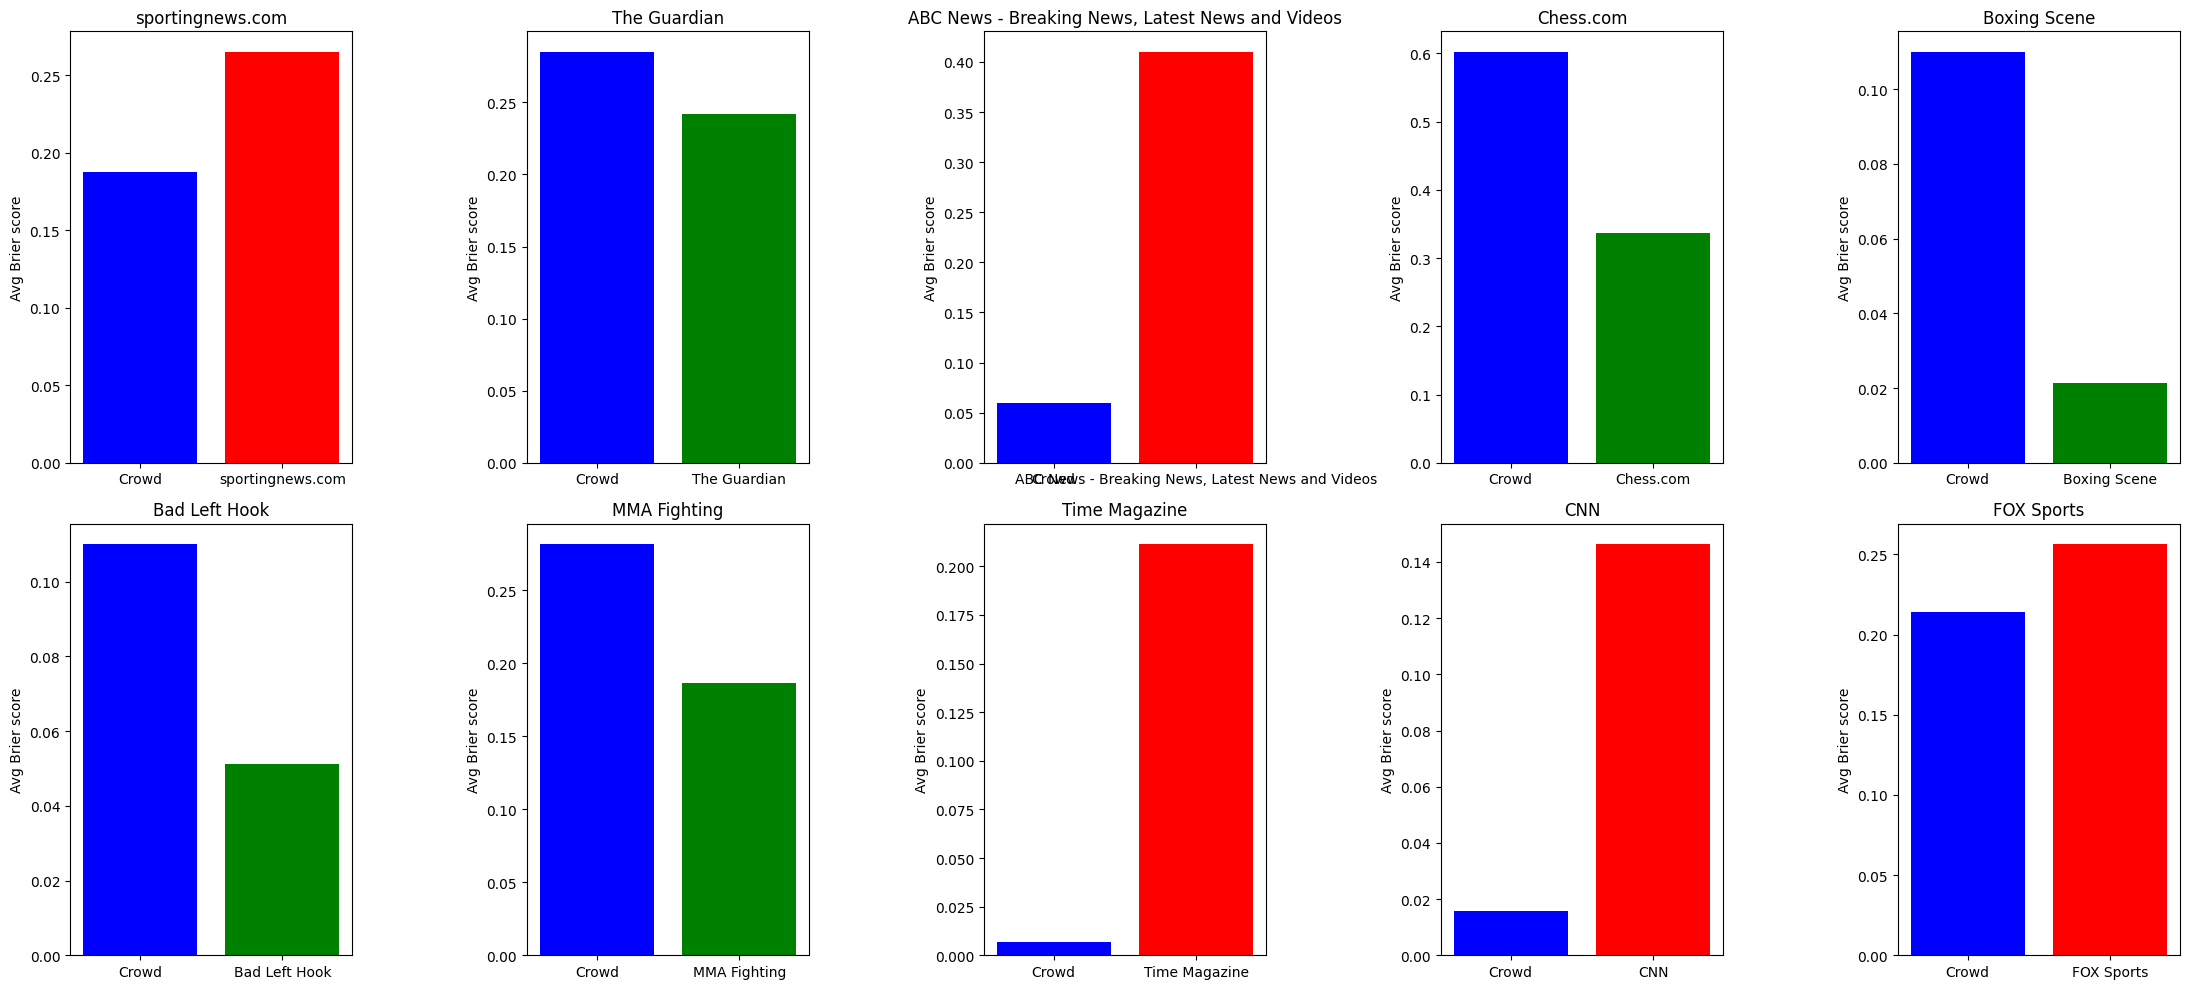

In [14]:
# ============================================================
# CELL 9.5 — Top-10 sources 
# ============================================================

import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime, timedelta

predictions_data = load_json(PREDICTIONS_FILE)

CUTOFF_DAYS = 7

# ============================================================
# 1) SOURCE -> QUESTIONS
# ============================================================

source_question_map = defaultdict(set)

for entry in predictions_data:
    q = entry["question"]

    for _, data in entry["retrieval_date_predictions"].items():
        for source, pred_data in data.get("source_predictions", {}).items():
            if pred_data.get("prediction") is not None:
                source_question_map[source].add(q)

top_sources = sorted(
    source_question_map.keys(),
    key=lambda s: len(source_question_map[s]),
    reverse=True
)[:10]

top_sources_set = set(top_sources)

print("\nTop 10 sources:")
for i, s in enumerate(top_sources, 1):
    print(f"{i:>2}. {s} ({len(source_question_map[s])} questions)")

# ============================================================
# 2) BUILD TABLE
# ============================================================

rows = []

for entry in predictions_data:

    q = entry["question"]
    resolution = float(entry["resolution"])

    q_original = next(qx for qx in all_questions if qx["question"] == q)

    community_predictions = json.loads(q_original["community_predictions"])

    eval_date = (
        datetime.strptime(q_original["date_resolve_at"], "%Y-%m-%d")
        - timedelta(days=CUTOFF_DAYS)
    ).strftime("%Y-%m-%d")

    crowd_pred = get_crowd_prediction_at_date(
        eval_date,
        community_predictions
    )

    crowd_brier = (
        brier_score(crowd_pred, resolution)
        if crowd_pred is not None else None
    )

    per_source = {}
    has_top = False

    for _, data in entry["retrieval_date_predictions"].items():
        for source, pred_data in data.get("source_predictions", {}).items():

            if source not in top_sources_set:
                continue

            pred = pred_data.get("prediction")
            if pred is None:
                continue

            per_source[source] = brier_score(pred, resolution)
            has_top = True

    if not has_top:
        continue

    row = {"question": q, "crowd": crowd_brier}

    for s in top_sources:
        row[s] = per_source.get(s, None)

    rows.append(row)

df = pd.DataFrame(rows)
df = df[["question", "crowd"] + top_sources]

print("\n" + "=" * 120)
print("TOP 10 SOURCES — FILTERED TABLE")
print("=" * 120)
print(df.to_string(index=False))

# ============================================================
# 3) PLOTS (COLORED AVERAGES)
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, src in enumerate(top_sources):

    ax = axes[i]

    crowd_vals = []
    source_vals = []

    for _, row in df.iterrows():
        if pd.notna(row.get(src)) and pd.notna(row.get("crowd")):
            crowd_vals.append(row["crowd"])
            source_vals.append(row[src])

    if len(source_vals) == 0:
        ax.set_title(f"{src}\n(no data)")
        ax.axis("off")
        continue

    crowd_avg = sum(crowd_vals) / len(crowd_vals)
    source_avg = sum(source_vals) / len(source_vals)

    # ---- color logic ----
    if source_avg < crowd_avg:
        src_color = "green"
    elif source_avg > crowd_avg:
        src_color = "red"
    else:
        src_color = "yellow"

    ax.bar(
        ["Crowd", src],
        [crowd_avg, source_avg],
        color=["blue", src_color]
    )

    ax.set_title(src)
    ax.set_ylabel("Avg Brier score")

plt.tight_layout()
plt.show()


SOURCE-LEVEL PERFORMANCE
                                          source   num_questions    num_articles    avg_brier
                                    Cartoon Brew               1               1       0.0025
                                        GOLF.com               1               1       0.0100
                                   NationalWorld               1               1       0.0100
                                        PGA Tour               1               1       0.0100
                                         Variety               1               2       0.0100
                          Boxing News（ボクシングニュース）               1               1       0.0100
                                    15rounds.com               1               1       0.0100
                                    Boxing Scene               2               2       0.0212
                            NBA Analysis Network               1               1       0.0225
                           The Com

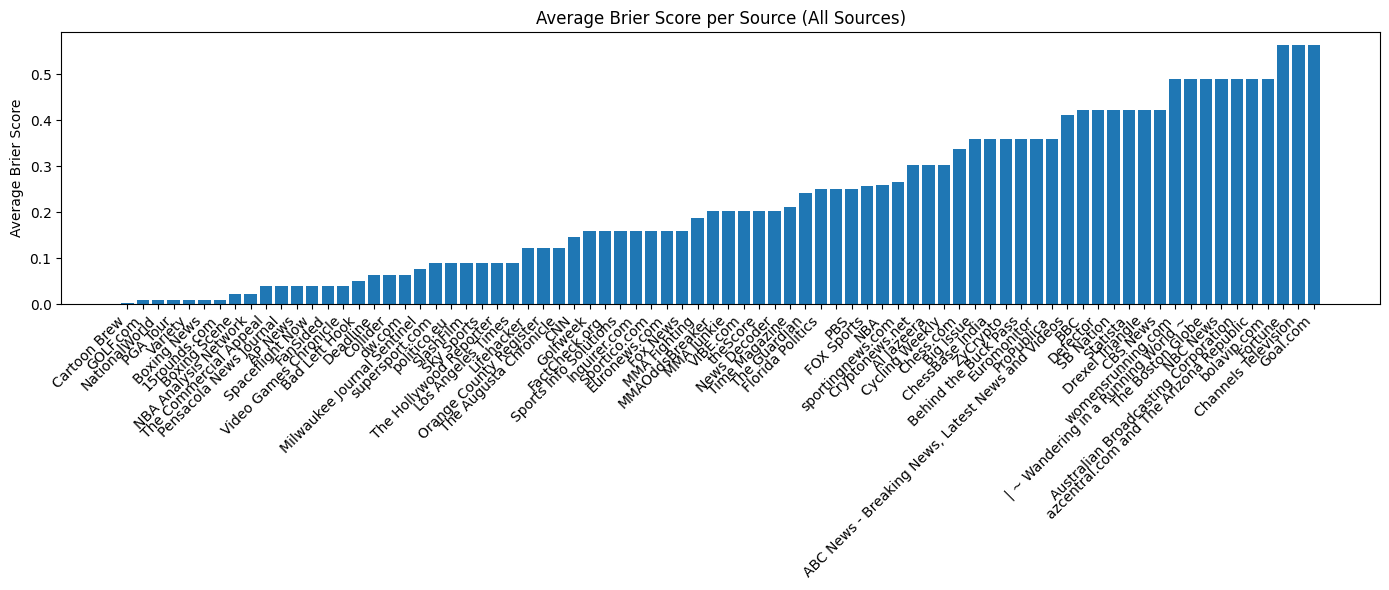


FILTERED SOURCES (>1 article AND >1 question)
                                                                source   num_questions    num_articles    avg_brier
                                                          Boxing Scene               2               2       0.0212
                                                         Bad Left Hook               2               4       0.0512
                                            Milwaukee Journal Sentinel               2               3       0.0763
                                                                   CNN               2               2       0.1462
                                                          MMA Fighting               2               3       0.1862
                                                         Time Magazine               2               2       0.2112
                                                          The Guardian               4               5       0.2419
                         

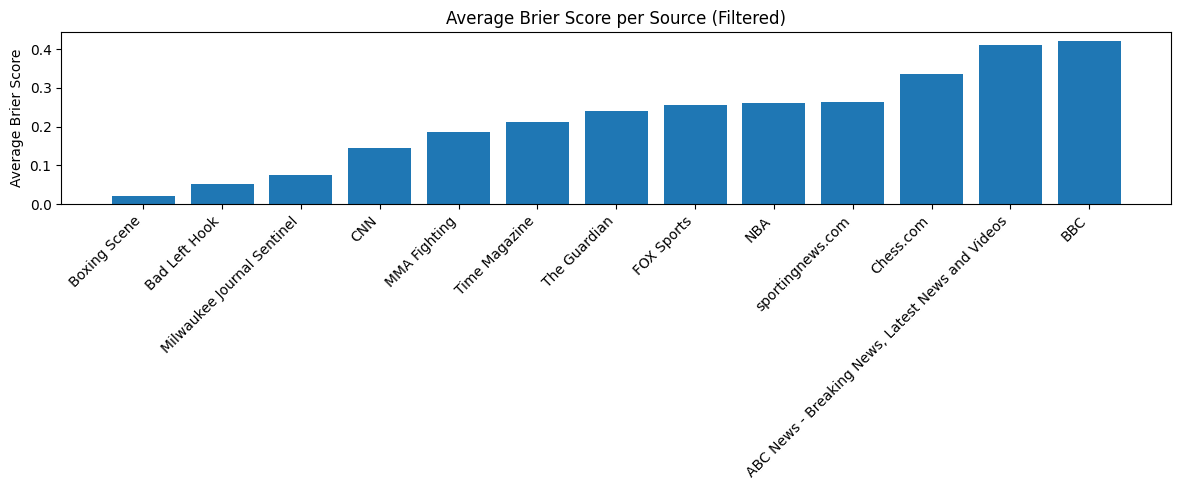

In [15]:
# ============================================================
# CELL 10 — Source-level performance overview
# ============================================================

import json
import warnings
import logging
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# ============================================================
# WARNING / FONT SUPPRESSION
# ============================================================

warnings.filterwarnings("ignore", category=UserWarning)

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ============================================================
# LOAD DATA
# ============================================================

predictions_data = load_json(PREDICTIONS_FILE)
summaries_data   = load_json(SUMMARIES_FILE)

summary_lookup = {
    entry["question"]: entry
    for entry in summaries_data
}

# ============================================================
# AGGREGATE SOURCE STATS
# ============================================================

source_stats = defaultdict(lambda: {
    "questions": set(),
    "article_count": 0,
    "brier_scores": []
})

for pred_entry in predictions_data:

    question   = pred_entry["question"]
    resolution = float(pred_entry["resolution"])

    sum_entry = summary_lookup.get(question)

    if not sum_entry:
        continue

    retrieval_preds = pred_entry.get("retrieval_date_predictions", {})
    retrieval_sums  = sum_entry.get("retrieval_date_summaries", {})

    for retrieval_date, pred_data in retrieval_preds.items():

        source_predictions = pred_data.get("source_predictions", {})

        date_sum_data = retrieval_sums.get(retrieval_date, {})
        summarised_articles = date_sum_data.get("summarised_articles", [])

        # count articles per source
        source_article_counts = defaultdict(int)

        for art in summarised_articles:
            src = art.get("source")

            if src and art.get("summary"):
                source_article_counts[src] += 1

        # process predictions
        for source, src_pred_data in source_predictions.items():

            prediction = src_pred_data.get("prediction")

            if prediction is None:
                continue

            bs = brier_score(prediction, resolution)

            source_stats[source]["questions"].add(question)
            source_stats[source]["article_count"] += source_article_counts.get(source, 0)
            source_stats[source]["brier_scores"].append(bs)

# ============================================================
# BUILD DATAFRAME
# ============================================================

rows = []

for source, stats in source_stats.items():

    if not stats["brier_scores"]:
        continue

    rows.append({
        "source": source,
        "num_questions": len(stats["questions"]),
        "num_articles": stats["article_count"],
        "avg_brier": sum(stats["brier_scores"]) / len(stats["brier_scores"]),
    })

df = pd.DataFrame(rows)

# ============================================================
# EMPTY CASE
# ============================================================

if df.empty:

    print("No source-level predictions found.")

else:

    # sort by best avg brier
    df = df.sort_values("avg_brier")

    # ========================================================
    # PRINT TABLE
    # ========================================================

    print("\n" + "=" * 100)
    print("SOURCE-LEVEL PERFORMANCE")
    print("=" * 100)

    print(
        df.to_string(
            index=False,
            col_space={
                "source": 40,
                "num_questions": 15,
                "num_articles": 15,
                "avg_brier": 12,
            },
            formatters={
                "avg_brier": lambda x: f"{x:.4f}"
            }
        )
    )

    # ========================================================
    # SAFE ASCII LABELS
    # ========================================================

    def safe_ascii(text):
        return text.encode("ascii", errors="ignore").decode("ascii") or "UNKNOWN"

    # ========================================================
    # PLOT 1 — ALL SOURCES
    # ========================================================

    plt.figure(figsize=(14, 6))

    plt.bar(
        [safe_ascii(s) for s in df["source"]],
        df["avg_brier"]
    )

    plt.xticks(rotation=45, ha="right")

    plt.ylabel("Average Brier Score")
    plt.title("Average Brier Score per Source (All Sources)")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # FILTERED DATAFRAME
    # ========================================================

    filtered_df = df[
        (df["num_articles"] > 1) &
        (df["num_questions"] > 1)
    ].copy()

    # ========================================================
    # PLOT 2 — FILTERED SOURCES
    # ========================================================

    if filtered_df.empty:

        print("\nNo sources satisfy the filtering criteria.")

    else:

        filtered_df = filtered_df.sort_values("avg_brier")

        print("\n" + "=" * 100)
        print("FILTERED SOURCES (>1 article AND >1 question)")
        print("=" * 100)

        print(
            filtered_df.to_string(
                index=False,
                col_space={
                    "source": 70,
                    "num_questions": 15,
                    "num_articles": 15,
                    "avg_brier": 12,
                },
                formatters={
                    "avg_brier": lambda x: f"{x:.4f}"
                }
            )
        )

        plt.figure(figsize=(12, 5))

        plt.bar(
            [safe_ascii(s) for s in filtered_df["source"]],
            filtered_df["avg_brier"]
        )

        plt.xticks(rotation=45, ha="right")

        plt.ylabel("Average Brier Score")
        plt.title("Average Brier Score per Source (Filtered)")

        plt.tight_layout()
        plt.show()